# Import Library

In [105]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [106]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
path = "/content/drive/MyDrive/DIBIMBING/THT"

In [108]:
customer_info = pd.read_csv(path + "/Customer_Info.csv")

location_data = pd.read_csv(path + "/Location_Data.csv")

online_services = pd.read_csv(path + "/Online_Services.csv")

payment_info = pd.read_csv(path + "/Payment_Info.csv")

service_options = pd.read_csv(path + "/Service_Options.csv")

status_analysis = pd.read_csv(path + "/Status_Analysis.csv")

# Business Understanding

## Problem Statement

Customer retention is an important aspect of maintaining business sustainability, as customer churn can impact revenue and long-term customer relationships.

Based on the available customer data, there is a need to understand the characteristics and behavior patterns of customers who churn compared to customers who remain active.

This analysis aims to identify factors associated with customer churn, such as customer satisfaction, contract type, tenure, service usage, and payment behavior, in order to provide insights that can support better customer retention strategies.

## Analysis Objectives

The objectives of this analysis are:

1. To understand customer characteristics and overall churn distribution

Analyze customer demographics, service usage, payment behavior, and customer status to understand the overall characteristics of the dataset.

2. To identify patterns associated with customer churn behavior

Analyze relationships between churn status and various customer attributes, including contract type, tenure, satisfaction level, pricing, payment method, and service usage.

3. To determine key factors associated with customer churn

Evaluate which customer attributes show stronger relationships with churn behavior through exploratory data analysis and correlation analysis.

4. To provide actionable business insights for customer retention improvement

Translate analytical findings into recommendations that can help identify customer segments requiring additional retention attention.

# Data Understanding

Melihat kolom-kolom pada tiap dataset untuk melihat primary key-nya

In [109]:
datasets = {
    "Customer Info": customer_info,
    "Location Data": location_data,
    "Online Services": online_services,
    "Payment Info": payment_info,
    "Service Options": service_options,
    "Status Analysis": status_analysis
}

for name, data in datasets.items():
    print("="*50)
    print(name)
    print("="*50)
    print(data.columns.tolist())
    print("\n")

Customer Info
['customer_id', 'gender', 'age', 'under_30', 'senior_citizen', 'partner', 'dependents', 'number_of_dependents', 'married']


Location Data
['customer_id', 'country', 'state', 'city', 'zip_code', 'total_population', 'latitude', 'longitude']


Online Services
['customer_id', 'phone_service', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'internet_type']


Payment Info
['customer_id', 'contract', 'paperless_billing', 'payment_method', 'monthly_ charges', 'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue']


Service Options
['customer_id', 'tenure', 'internet_service', 'phone_service', 'multiple_lines', 'avg_monthly_gb_download', 'unlimited_data', 'offer', 'referred_a_friend', 'number_of_referrals']


Status Analysis
['customer_id', 'satisfaction_score', 'cltv', 'customer_st

In [110]:
for name, data in datasets.items():
    print("="*50)
    print(name)
    print("="*50)
    print(data.dtypes)
    print("\n")

Customer Info
customer_id             object
gender                  object
age                      int64
under_30                object
senior_citizen          object
partner                 object
dependents              object
number_of_dependents     int64
married                 object
dtype: object


Location Data
customer_id          object
country              object
state                object
city                 object
zip_code              int64
total_population      int64
latitude            float64
longitude           float64
dtype: object


Online Services
customer_id             object
phone_service           object
internet_service        object
online_security         object
online_backup           object
device_protection       object
premium_tech_support    object
streaming_tv            object
streaming_movies        object
streaming_music         object
internet_type           object
dtype: object


Payment Info
customer_id                           object
contra

** Data Type Evaluation**

The data types of all variables were reviewed to ensure they were appropriate
for the analysis.

Numerical variables used for statistical analysis, such as tenure, monthly
charges, total charges, and satisfaction score, were stored as numerical data
types. Categorical variables, such as contract type, payment method, internet
type, and churn status, were stored as categorical/object variables.

Based on this evaluation, the variables were considered suitable for the
subsequent exploratory data analysis.

In [111]:
for name, data in datasets.items():
    print(
        name,
        "Jumlah customer unik:",
        data['customer_id'].nunique()
    )

Customer Info Jumlah customer unik: 7043
Location Data Jumlah customer unik: 7043
Online Services Jumlah customer unik: 7043
Payment Info Jumlah customer unik: 7043
Service Options Jumlah customer unik: 7043
Status Analysis Jumlah customer unik: 7043


In [112]:
datasets = {
    "Customer Info": customer_info,
    "Location Data": location_data,
    "Online Services": online_services,
    "Payment Info": payment_info,
    "Service Options": service_options,
    "Status Analysis": status_analysis
}

summary_info = []

for name, data in datasets.items():
    summary_info.append({
        "Dataset": name,
        "Rows": data.shape[0],
        "Columns": data.shape[1],
        "Missing Value": data.isnull().sum().sum(),
        "Duplicate": data.duplicated().sum()
    })

summary_info = pd.DataFrame(summary_info)

summary_info

,Dataset,Rows,Columns,Missing Value,Duplicate
0,Customer Info,7043,9,0,0
1,Location Data,7043,8,0,0
2,Online Services,7043,11,1526,0
3,Payment Info,7043,11,0,0
4,Service Options,7043,10,3877,0
5,Status Analysis,7043,9,5174,0


**Duplicate Data Evaluation**

Duplicate records were checked both before and after the dataset merging process.

No duplicate records were identified in the original datasets. After merging,
customer ID uniqueness was also evaluated to ensure that each row represented
one unique customer.

Based on the evaluation, no duplicate removal was required.

In [113]:
for name, data in datasets.items():
    print("="*50)
    print(name)
    print("="*50)

    missing = data.isnull().sum()
    print(missing[missing > 0])
    print("\n")

Customer Info
Series([], dtype: int64)


Location Data
Series([], dtype: int64)


Online Services
internet_type    1526
dtype: int64


Payment Info
Series([], dtype: int64)


Service Options
offer    3877
dtype: int64


Status Analysis
churn_reason    5174
dtype: int64




In [114]:
online_services[
    online_services['internet_type'].isnull()
]['internet_service'].value_counts()

,count
internet_service,
No,1526


In [115]:
service_options[
    service_options['offer'].isnull()
]['internet_service'].value_counts()

,count
internet_service,
Yes,3024
No,853


In [116]:
service_options['offer'].value_counts(dropna=False)

,count
offer,
NaN,3877
Offer B,824
Offer E,805
Offer D,602
Offer A,520
Offer C,415


In [117]:
status_analysis[
    status_analysis['churn_reason'].isnull()
]['churn_label'].value_counts()

,count
churn_label,
No,5174


# Data Cleaning/Preprocessing

In [118]:
online_services['internet_type'] = online_services['internet_type'].fillna(
    'No Internet Service'
)

service_options['offer'] = service_options['offer'].fillna(
    'No Offer'
)

status_analysis['churn_reason'] = status_analysis['churn_reason'].fillna(
    'Not Churned'
)

** Missing Value Treatment Summary**

Missing values were evaluated based on their proportion and the meaning of
each variable. The selected treatment was applied before conducting the main
EDA to prevent missing observations from affecting the analysis.

After preprocessing, the dataset was checked again to ensure that the
remaining missing values would not interfere with the subsequent analysis.

In [119]:
for name, data in datasets.items():
    print("="*50)
    print(name)
    print(data.isnull().sum()[data.isnull().sum() > 0])

Customer Info
Series([], dtype: int64)
Location Data
Series([], dtype: int64)
Online Services
Series([], dtype: int64)
Payment Info
Series([], dtype: int64)
Service Options
Series([], dtype: int64)
Status Analysis
Series([], dtype: int64)


## Merge Data

In [120]:
# Merge Customer Info dengan Location Data
df = customer_info.merge(
    location_data,
    on='customer_id',
    how='left'
)

# Tambahkan Online Services
df = df.merge(
    online_services,
    on='customer_id',
    how='left'
)

# Tambahkan Payment Info
df = df.merge(
    payment_info,
    on='customer_id',
    how='left'
)

# Tambahkan Service Options
df = df.merge(
    service_options,
    on='customer_id',
    how='left'
)

# Tambahkan Status Analysis
df = df.merge(
    status_analysis,
    on='customer_id',
    how='left'
)

In [121]:
df.shape

(7043, 53)

In [122]:
df.columns

Index(['customer_id', 'gender', 'age', 'under_30', 'senior_citizen', 'partner',
       'dependents', 'number_of_dependents', 'married', 'country', 'state',
       'city', 'zip_code', 'total_population', 'latitude', 'longitude',
       'phone_service_x', 'internet_service_x', 'online_security',
       'online_backup', 'device_protection', 'premium_tech_support',
       'streaming_tv', 'streaming_movies', 'streaming_music', 'internet_type',
       'contract', 'paperless_billing', 'payment_method', 'monthly_ charges',
       'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'tenure', 'internet_service_y', 'phone_service_y',
       'multiple_lines', 'avg_monthly_gb_download', 'unlimited_data', 'offer',
       'referred_a_friend', 'number_of_referrals', 'satisfaction_score',
       'cltv', 'customer_status', 'churn_score', 'churn_label', 'churn_value',
       'churn_category', 'chu

In [123]:
df['customer_id'].duplicated().sum()

np.int64(0)

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   partner                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   married                            7043 non-null   object 
 9   country                            7043 non-null   object 
 10  state                              7043 non-null   object 
 11  city                               7043 non-null   objec

In [125]:
# Validate the merged dataset
merge_validation = pd.DataFrame({
    "Metric": [
        "Total rows after merge",
        "Unique customer IDs",
        "Duplicated customer IDs"
    ],
    "Value": [
        len(df),
        df["customer_id"].nunique(),
        df["customer_id"].duplicated().sum()
    ]
})

merge_validation

,Metric,Value
0,Total rows after merge,7043
1,Unique customer IDs,7043
2,Duplicated customer IDs,0


**Merge Validation**

The datasets were merged using `customer_id` as the common key. After the
merging process, the resulting dataset was validated to ensure that the merge
did not introduce duplicated customers or unexpected changes in the number
of observations.

The merged dataset contains 7,043 rows and 7,043 unique customer IDs, with
no duplicated customer IDs identified.

This confirms that each row in the merged dataset represents one unique
customer and that the merging process did not create duplicate customer
records.

## Cleaning After Merge

In [126]:
(df['phone_service_x'] == df['phone_service_y']).value_counts()

,count
True,7043


In [127]:
(df['internet_service_x'] == df['internet_service_y']).value_counts()

,count
True,7043


In [128]:
df.drop(
    columns=[
        'phone_service_y',
        'internet_service_y'
    ],
    inplace=True
)

In [129]:
df.rename(
    columns={
        'phone_service_x':'phone_service',
        'internet_service_x':'internet_service'
    },
    inplace=True
)

In [130]:
df.rename(
    columns={
        'monthly_ charges':'monthly_charges'
    },
    inplace=True
)

In [131]:
df.shape

(7043, 51)

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 51 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   partner                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   married                            7043 non-null   object 
 9   country                            7043 non-null   object 
 10  state                              7043 non-null   object 
 11  city                               7043 non-null   objec

In [133]:
df.isnull().sum().sum()

np.int64(0)

## Dataset Clean

In [134]:
df_clean = df.copy()

## Feature Engineering

In [135]:
# Create customer tenure segments
bins = [0, 12, 24, 48, float("inf")]
labels = ["0-12 Months", "13-24 Months", "25-48 Months", "49+ Months"]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["tenure", "tenure_group"]].head()

,tenure,tenure_group
0,9,0-12 Months
1,9,0-12 Months
2,4,0-12 Months
3,13,13-24 Months
4,3,0-12 Months


In [136]:
df["tenure_group"].value_counts().sort_index()

,count
tenure_group,
0-12 Months,2186
13-24 Months,1024
25-48 Months,1594
49+ Months,2239


In [137]:
print("Missing tenure group:", df["tenure_group"].isnull().sum())

Missing tenure group: 0


**Feature Engineering "Customer Tenure Group"**

To support customer segmentation and improve interpretability, the continuous
`tenure` variable was grouped into four customer lifecycle segments:

- **0–12 Months:** New customers
- **13–24 Months:** Early-tenure customers
- **25–48 Months:** Established customers
- **49+ Months:** Long-tenure customers

The original `tenure` variable was retained to preserve the detailed numerical
information, while `tenure_group` was created as an additional variable for
segmentation analysis and dashboard visualization.

## Outlier Analysis

In [138]:
numeric_cols = df_clean.select_dtypes(
    include=['int64', 'float64']
).columns

numeric_cols

Index(['age', 'number_of_dependents', 'zip_code', 'total_population',
       'latitude', 'longitude', 'monthly_charges',
       'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'tenure', 'avg_monthly_gb_download',
       'number_of_referrals', 'satisfaction_score', 'cltv', 'churn_score',
       'churn_value'],
      dtype='object')

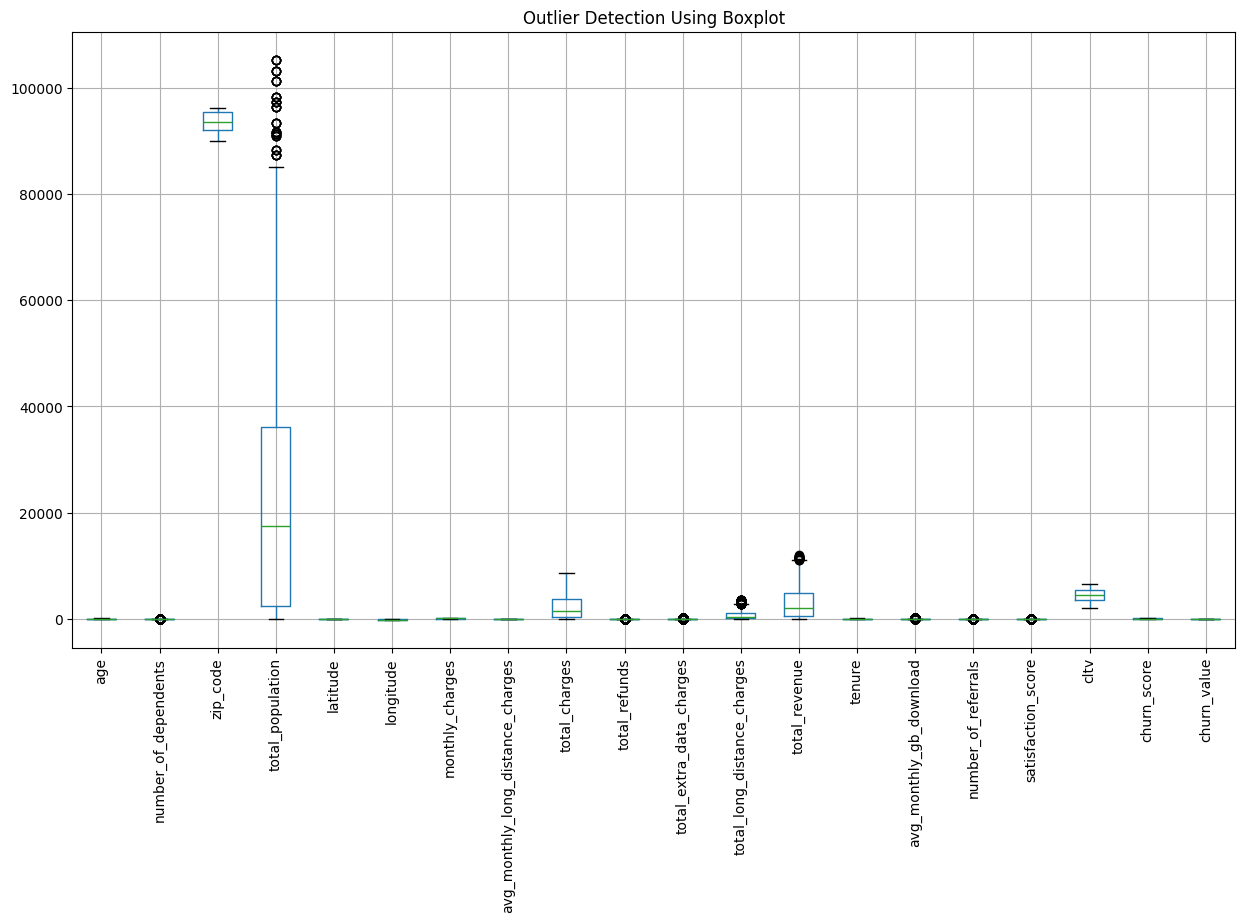

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

df_clean[numeric_cols].boxplot()

plt.xticks(rotation=90)

plt.title("Outlier Detection Using Boxplot")

plt.show()

In [140]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    outlier_summary[col] = len(outliers)

outlier_summary

{'age': 0,
 'number_of_dependents': 1627,
 'zip_code': 0,
 'total_population': 57,
 'latitude': 0,
 'longitude': 0,
 'monthly_charges': 0,
 'avg_monthly_long_distance_charges': 0,
 'total_charges': 0,
 'total_refunds': 525,
 'total_extra_data_charges': 728,
 'total_long_distance_charges': 196,
 'total_revenue': 21,
 'tenure': 0,
 'avg_monthly_gb_download': 362,
 'number_of_referrals': 676,
 'satisfaction_score': 922,
 'cltv': 0,
 'churn_score': 0,
 'churn_value': 0}

In [141]:
outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=['Feature','Outlier_Count']
)

outlier_df.sort_values(
    by='Outlier_Count',
    ascending=False
)

,Feature,Outlier_Count
1,number_of_dependents,1627
16,satisfaction_score,922
10,total_extra_data_charges,728
15,number_of_referrals,676
9,total_refunds,525
14,avg_monthly_gb_download,362
11,total_long_distance_charges,196
3,total_population,57
12,total_revenue,21
0,age,0


**Outlier Evaluation**

Potential outliers in numerical variables were identified using the
Interquartile Range (IQR) method.

However, the identified values were not automatically removed. The values
were still within plausible ranges for customer behavior and may represent
valid customer segments rather than data-entry errors.

Removing these observations could eliminate meaningful information,
particularly customers with unusually high charges or different usage
patterns. Therefore, the identified outliers were retained for the analysis.

## Data Preprocessing Summary

The preprocessing stage was conducted to ensure that the dataset was
consistent and suitable for exploratory analysis.

The main steps included:

1. Evaluating missing values and applying the appropriate treatment.
2. Checking duplicated rows and duplicated customer IDs.
3. Reviewing data types to ensure numerical and categorical variables were
   represented appropriately.
4. Identifying potential outliers using the IQR method.
5. Retaining valid outliers that may represent meaningful customer behavior.

After these steps, the cleaned dataset was considered ready for exploratory
data analysis.

# Exploratory Data Analysis (EDA)

## Univariate Analysis

### Numerical Analysis

In [142]:
numerical_cols = df_clean.select_dtypes(
    include=['int64','float64']
).columns

numerical_cols

Index(['age', 'number_of_dependents', 'zip_code', 'total_population',
       'latitude', 'longitude', 'monthly_charges',
       'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'tenure', 'avg_monthly_gb_download',
       'number_of_referrals', 'satisfaction_score', 'cltv', 'churn_score',
       'churn_value'],
      dtype='object')

In [143]:
numerical_summary = df_clean[numerical_cols].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
number_of_dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
zip_code,7043.0,93486.071134,1856.768045,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
total_population,7043.0,22139.814568,21152.174407,11.000000,2344.000000,17554.000000,36125.000000,105285.000000
latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
monthly_charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
avg_monthly_long_distance_charges,7043.0,22.958954,15.448113,0.000000,9.210000,22.890000,36.395000,49.990000
total_charges,7043.0,2280.381264,2266.220462,18.800000,400.150000,1394.550000,3786.600000,8684.800000
total_refunds,7043.0,1.962182,7.902614,0.000000,0.000000,0.000000,0.000000,49.790000


In [144]:
eda_numeric = [
    'age',
    'tenure',
    'monthly_charges',
    'total_revenue',
    'satisfaction_score',
    'cltv'
]

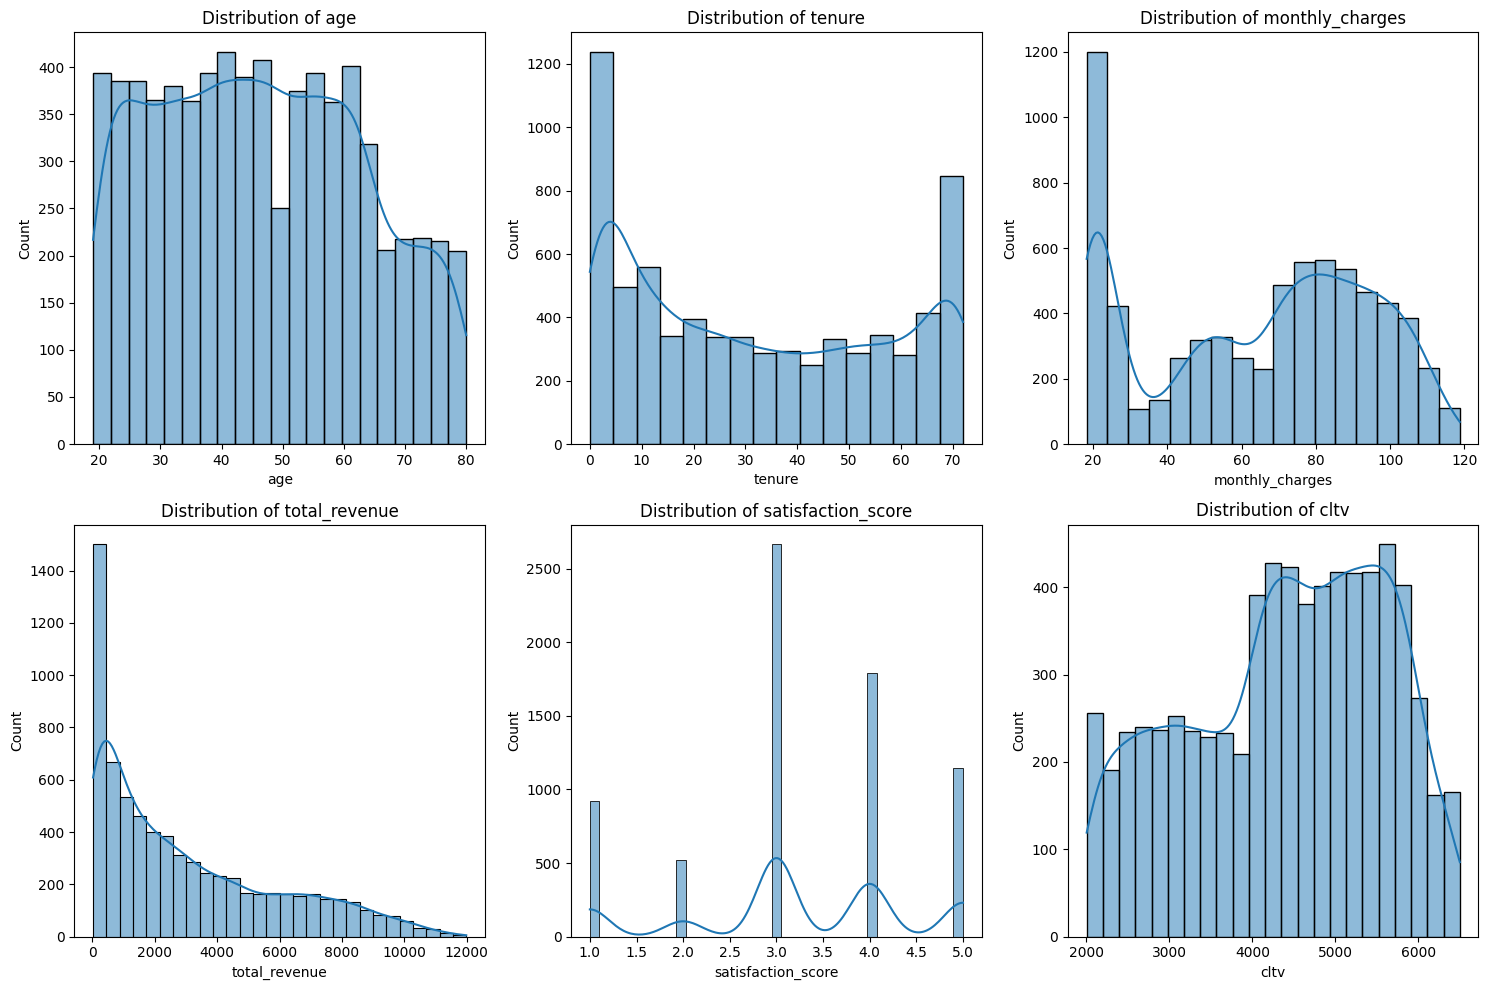

In [145]:
plt.figure(figsize=(15,10))

for i, col in enumerate(eda_numeric,1):
    plt.subplot(2,3,i)
    sns.histplot(
        data=df_clean,
        x=col,
        kde=True
    )
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

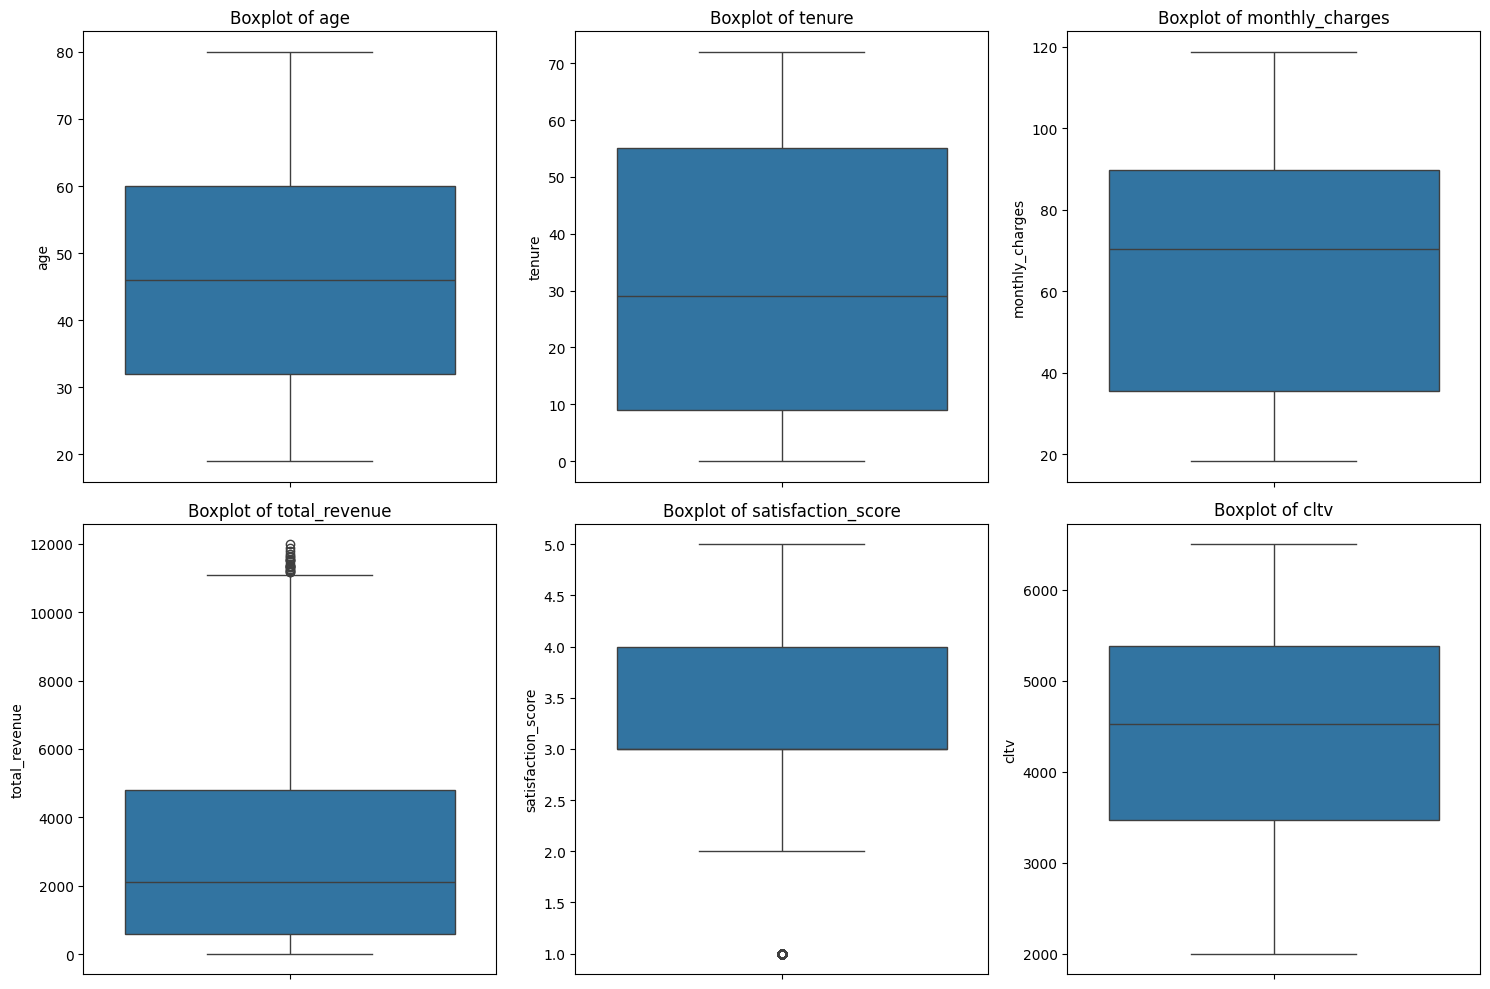

In [146]:
plt.figure(figsize=(15,10))

for i, col in enumerate(eda_numeric,1):
    plt.subplot(2,3,i)
    sns.boxplot(
        data=df_clean,
        y=col
    )
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [147]:
df_clean['churn_label'].value_counts()

,count
churn_label,
No,5174
Yes,1869


In [148]:
df_clean['churn_label'].value_counts(normalize=True)*100

,proportion
churn_label,
No,73.463013
Yes,26.536987


**Customer Churn Distribution**

Based on the customer churn distribution analysis, the majority of customers remained active, with **73.46% classified as No Churn**, while **26.54% of customers experienced churn**. This indicates that the dataset has an **imbalanced class distribution**, although the proportion of churned customers is still significant enough to support further analysis.


### Categorical Analysis

In [149]:
categorical_cols = df_clean.select_dtypes(
    include='object'
).columns

categorical_cols

Index(['customer_id', 'gender', 'under_30', 'senior_citizen', 'partner',
       'dependents', 'married', 'country', 'state', 'city', 'phone_service',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'premium_tech_support', 'streaming_tv',
       'streaming_movies', 'streaming_music', 'internet_type', 'contract',
       'paperless_billing', 'payment_method', 'multiple_lines',
       'unlimited_data', 'offer', 'referred_a_friend', 'customer_status',
       'churn_label', 'churn_category', 'churn_reason'],
      dtype='object')

In [150]:
categorical_cols = df_clean.select_dtypes(include='object').columns

for col in categorical_cols:
    print("="*50)
    print(col)
    print(df_clean[col].value_counts().head(10))
    print()

customer_id
customer_id
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
9967-ATRFS    1
9965-YOKZB    1
9964-WBQDJ    1
9962-BFPDU    1
9961-JBNMK    1
Name: count, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

under_30
under_30
No     5642
Yes    1401
Name: count, dtype: int64

senior_citizen
senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64

partner
partner
No     3641
Yes    3402
Name: count, dtype: int64

dependents
dependents
No     5416
Yes    1627
Name: count, dtype: int64

married
married
No     3641
Yes    3402
Name: count, dtype: int64

country
country
United States    7043
Name: count, dtype: int64

state
state
California    7043
Name: count, dtype: int64

city
city
Los Angeles      293
San Diego        285
San Jose         112
Sacramento       108
San Francisco    104
Fresno            61
Long Beach        60
Oakland           52
Escondido         51
Stockton          44
Name: count, dtype

In [151]:
cat_eda = [
    'contract',
    'internet_service',
    'payment_method',
    'customer_status',
    'gender',
    'offer',
    'customer_status'
]

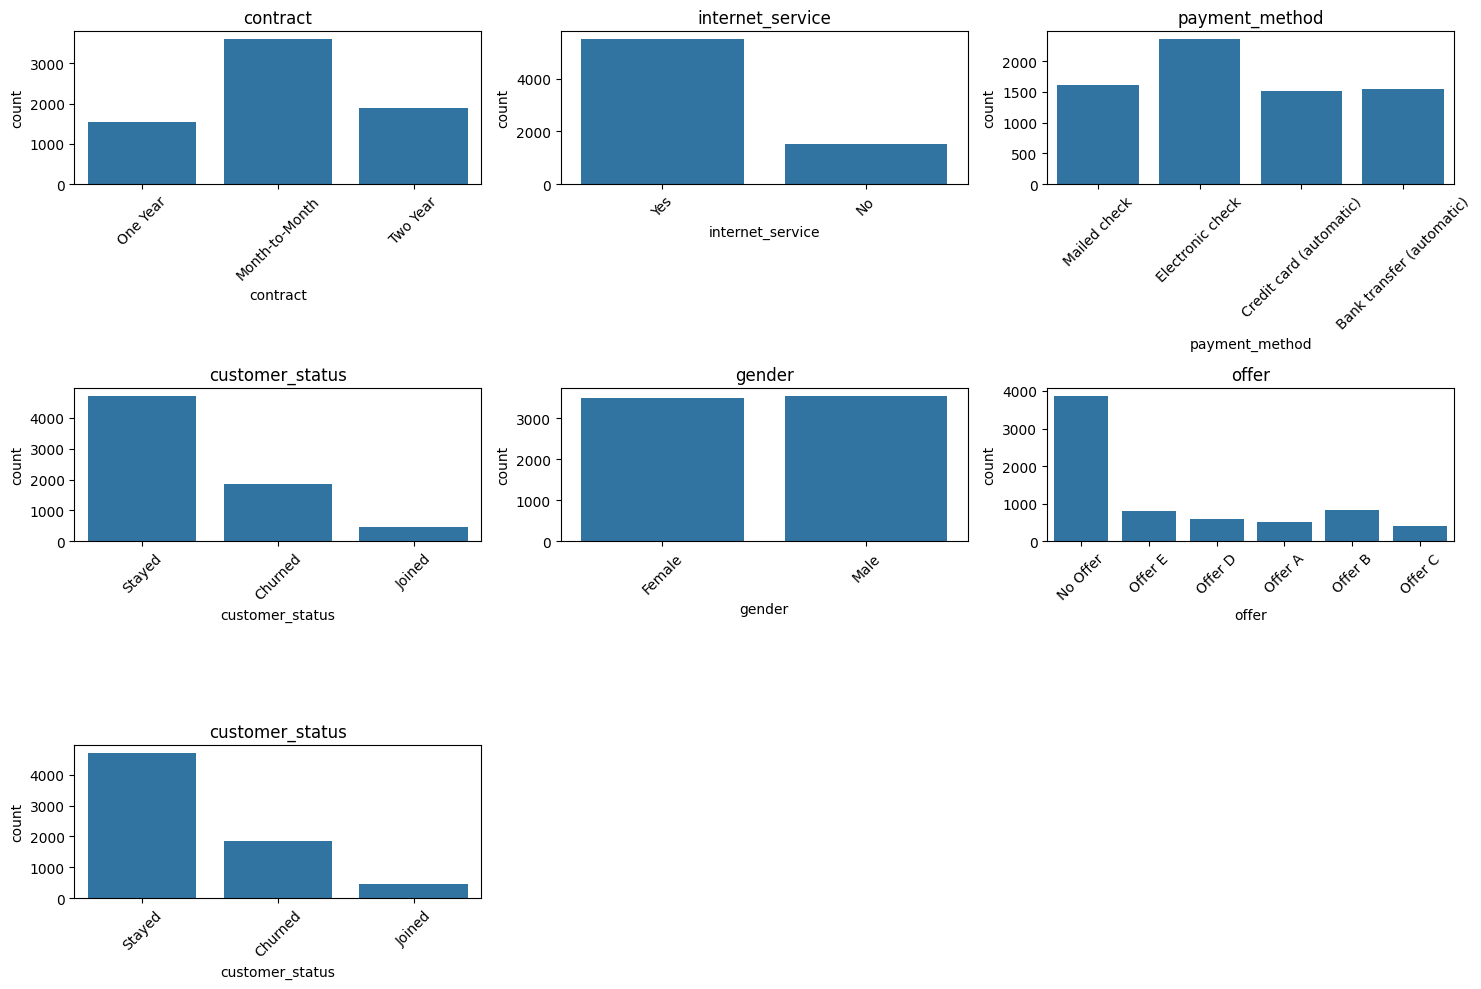

In [152]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cat_eda,1):
    plt.subplot(3,3,i)
    sns.countplot(
        data=df_clean,
        x=col
    )
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bivariate Analysis

### Contract vs Churn

In [153]:
pd.crosstab(
    df_clean['contract'],
    df_clean['churn_label'],
    normalize='index'
)*100

churn_label,No,Yes
contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


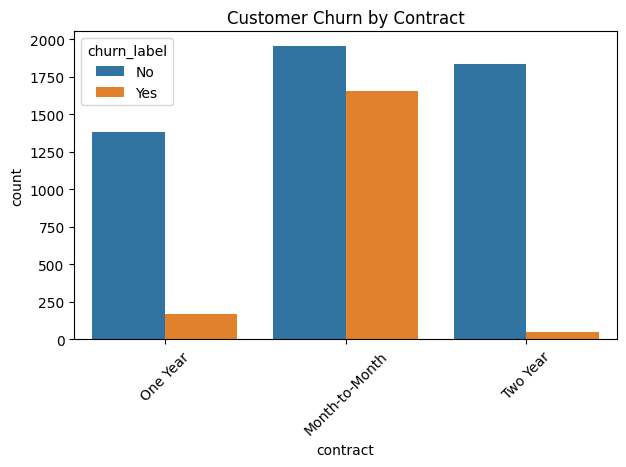

In [154]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x='contract',
    hue='churn_label'
)

plt.title('Customer Churn by Contract')
plt.xticks(rotation=45)

plt.show()

Insight

Customers with Month-to-Month contracts show substantially higher churn rates compared to customers with longer-term contracts.

Interpretation

The churn rate decreases as contract commitment increases. Customers on Month-to-Month contracts have a churn rate of 45.84%, compared with 10.71% for One Year contracts and 2.55% for Two Year contracts. This indicates that contract type is strongly associated with customer churn, with customers on shorter-term contracts showing a higher tendency to churn.

### Tenure vs Churn

In [155]:
tenure_churn = (
    df.groupby("tenure_group", observed=False)["churn_value"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

tenure_churn.columns = [
    "Tenure Group",
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

tenure_churn["Churn Rate"] = (
    tenure_churn["Churn Rate"] * 100
).round(2)

tenure_churn

,Tenure Group,Total Customers,Churned Customers,Churn Rate
0,0-12 Months,2186,1037,47.44
1,13-24 Months,1024,294,28.71
2,25-48 Months,1594,325,20.39
3,49+ Months,2239,213,9.51


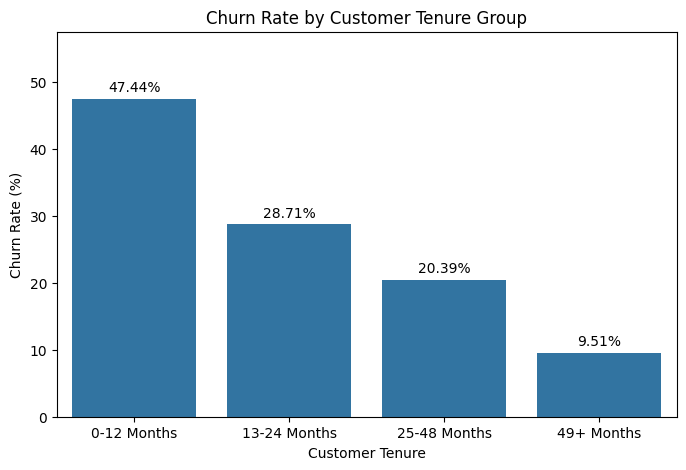

In [156]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=tenure_churn,
    x="Tenure Group",
    y="Churn Rate"
)

plt.title("Churn Rate by Customer Tenure Group")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.ylim(0, tenure_churn["Churn Rate"].max() + 10)
plt.show()

Insight:

Churn rate decreases consistently as customer tenure increases. Customers
within their first 12 months have the highest churn rate at **47.44%**,
followed by **28.71%** among customers with 13–24 months of tenure.

The churn rate continues to decline to **20.39%** for customers with
25–48 months of tenure and reaches only **9.51%** among customers who have
stayed for more than 48 months.

This pattern indicates that churn is particularly concentrated during the
earlier stages of the customer lifecycle, making early-tenure customers an
important segment for retention efforts.

### Monthly Charges vs Churn

In [157]:
df_clean.groupby('churn_label')['monthly_charges'].mean()

,monthly_charges
churn_label,
No,61.265124
Yes,74.441332


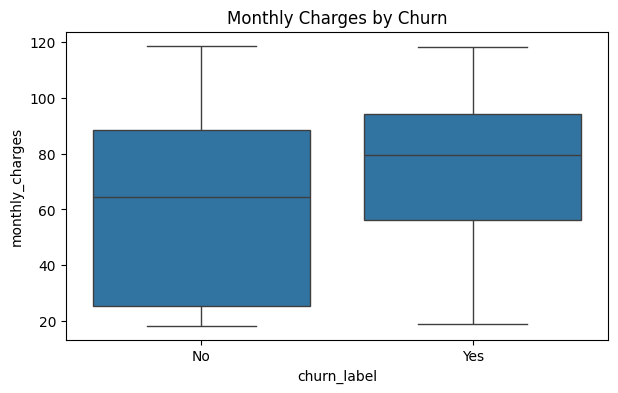

In [158]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df_clean,
    x='churn_label',
    y='monthly_charges'
)

plt.title('Monthly Charges by Churn')

plt.show()

Insight:
Customers who churn have a higher average monthly charge.

**Difference:**
74.44 − 61.27 = **13.18**

Interpretation:
Customers with higher monthly charges show a higher churn rate. This may indicate that **pricing or perceived value of the service** is associated with customer churn.


### Payment Method vs Churn

In [159]:
pd.crosstab(
    df_clean['payment_method'],
    df_clean['churn_label'],
    normalize='index'
)*100

churn_label,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


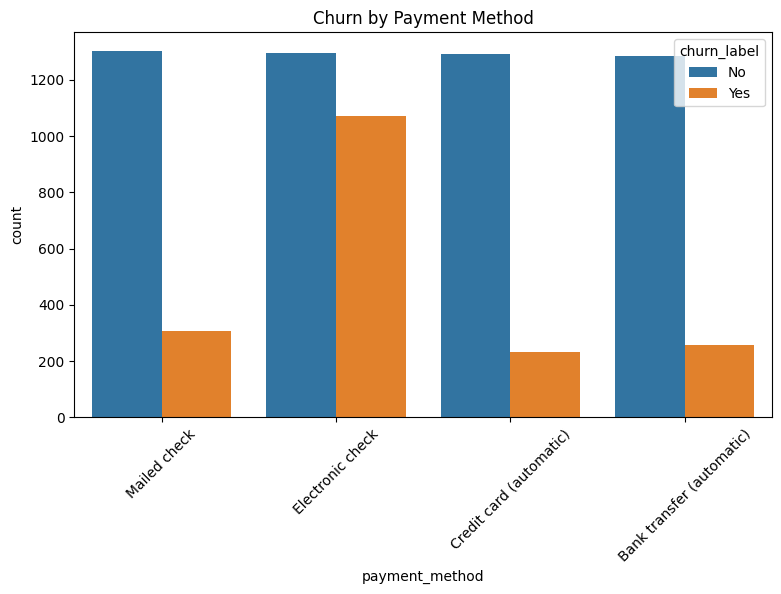

In [160]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df_clean,
    x='payment_method',
    hue='churn_label'
)

plt.title('Churn by Payment Method')

plt.xticks(rotation=45)

plt.show()

Insight:
Customers using Electronic Check have the highest churn rate at 45.29%.

Interpretation:
The Electronic Check payment method shows a higher churn rate compared with automatic payment methods.

### Internet Type vs Churn

In [161]:
pd.crosstab(
    df_clean['internet_type'],
    df_clean['churn_label'],
    normalize='index'
)*100

churn_label,No,Yes
internet_type,,
Cable,74.337349,25.662651
DSL,81.416465,18.583535
Fiber Optic,59.275124,40.724876
No Internet Service,92.595020,7.404980


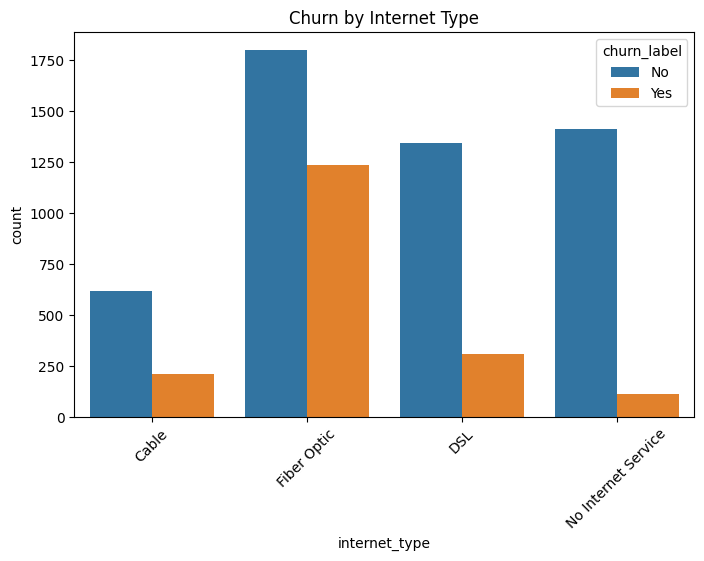

In [162]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='internet_type',
    hue='churn_label'
)

plt.title('Churn by Internet Type')

plt.xticks(rotation=45)

plt.show()

Insight:
Customers using Fiber Optic service have the highest churn rate at 40.72%, followed by Cable at 25.66%, DSL at 18.58%, and No Internet Service at 7.40%.

Interpretation:
Fiber Optic customers show a higher churn rate compared to customers using other internet service types. This pattern indicates that internet service type is associated with different levels of customer churn and should be examined together with customer satisfaction and service experience.

### Satisfaction Score vs Churn

In [163]:
df_clean.groupby('churn_label')['satisfaction_score'].mean()

,satisfaction_score
churn_label,
No,3.789911
Yes,1.736223


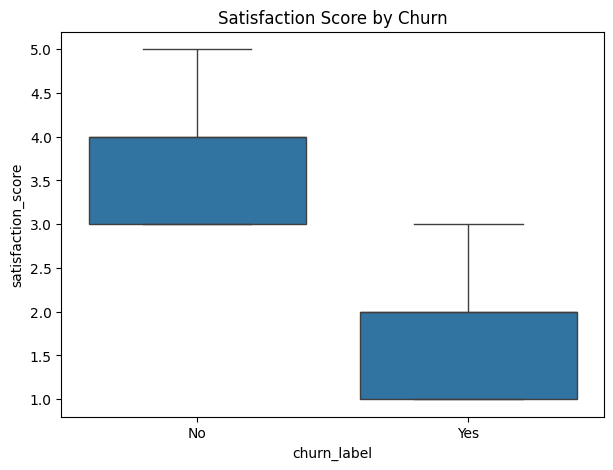

In [164]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_clean,
    x='churn_label',
    y='satisfaction_score'
)

plt.title('Satisfaction Score by Churn')

plt.show()

Insight

Churned customers have substantially lower satisfaction scores than customers who stayed.

Interpretation

Customers who churned had an average satisfaction score of 1.74, compared with 3.77 among customers who stayed. The approximately 2-point difference indicates a strong association between customer satisfaction and churn. This suggests that monitoring customer satisfaction throughout the customer lifecycle can help identify segments that may require retention attention.

### Offer vs Churn

In [165]:
pd.crosstab(
    df_clean['offer'],
    df_clean['churn_label'],
    normalize='index'
)*100

churn_label,No,Yes
offer,,
No Offer,72.891411,27.108589
Offer A,93.269231,6.730769
Offer B,87.742718,12.257282
Offer C,77.108434,22.891566
Offer D,73.255814,26.744186
Offer E,47.080745,52.919255


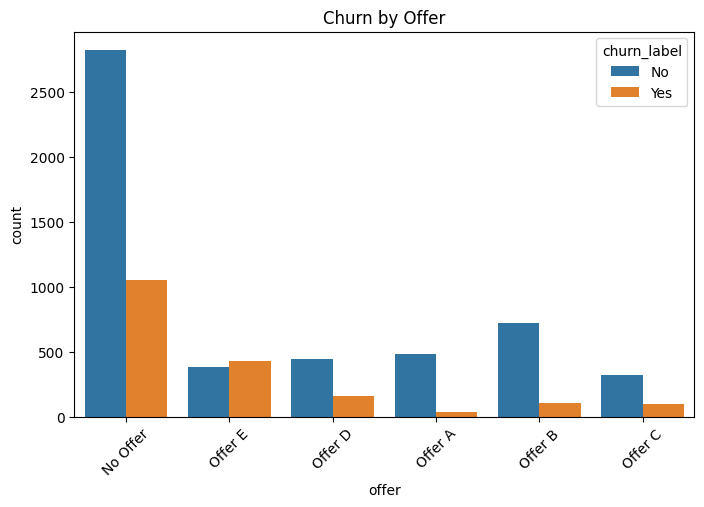

In [166]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='offer',
    hue='churn_label'
)

plt.title('Churn by Offer')

plt.xticks(rotation=45)

plt.show()

Insight

Customers receiving Offer E show the highest churn rate among all offer groups.

Interpretation

Offer E has the highest observed churn rate at 52.92%, substantially higher than other offer groups. In comparison, customers receiving Offer A and Offer B have lower churn rates of 6.73% and 12.26%. This pattern suggests that customers receiving Offer E represent a segment that requires further investigation, particularly regarding customer characteristics, contract type, tenure, satisfaction, and service conditions.

 ## Correlation Analysis

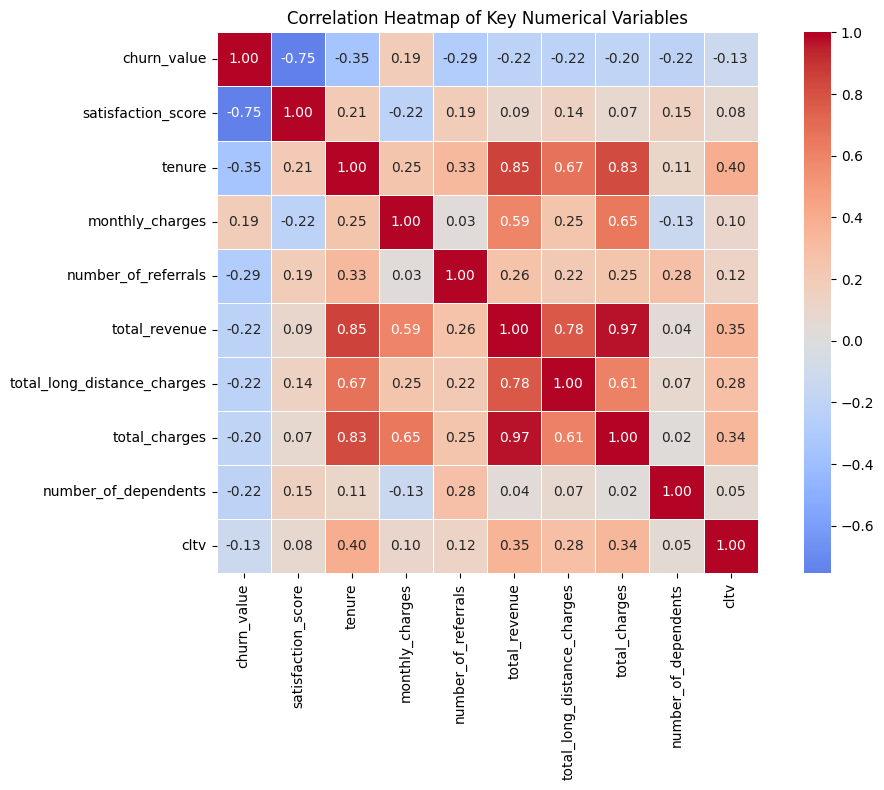

In [167]:
corr_cols = [
    'churn_value',
    'satisfaction_score',
    'tenure',
    'monthly_charges',
    'number_of_referrals',
    'total_revenue',
    'total_long_distance_charges',
    'total_charges',
    'number_of_dependents',
    'cltv'
]

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap of Key Numerical Variables')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()
plt.show()

Insight

Customer satisfaction and tenure show the strongest negative relationships with churn among the key numerical variables, while monthly charges show a positive relationship with churn.

Interpretation

The correlation analysis shows that satisfaction score has the strongest negative relationship with churn among the selected business-related variables (r = -0.75), followed by tenure (r = -0.35). Number of referrals also shows a negative relationship with churn (r = -0.29), while monthly charges show a positive relationship (r = 0.19). These results indicate that lower satisfaction, shorter tenure, fewer referrals, and higher monthly charges are associated with higher churn values. However, correlation does not imply causation, so these variables should be interpreted as associated patterns rather than direct causes of churn.

## Churn Pattern Analysis

###  Contract & Tenure Pattern

In [168]:
df_clean.groupby(
    ['contract','churn_label']
)['tenure'].mean()

contract        churn_label
Month-to-Month  No             20.172379
                Yes            14.016918
One Year        No             40.800578
                Yes            44.963855
Two Year        No             53.668665
                Yes            61.270833
Name: tenure, dtype: float64

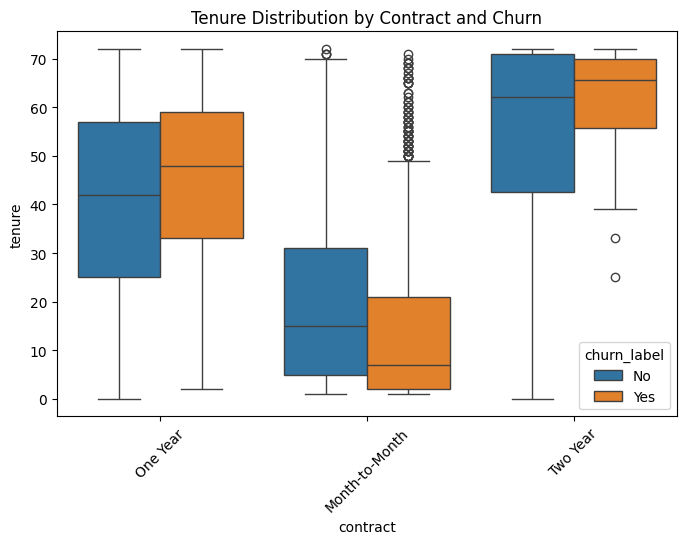

In [169]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='contract',
    y='tenure',
    hue='churn_label'
)

plt.title('Tenure Distribution by Contract and Churn')

plt.xticks(rotation=45)

plt.show()

Analysis of contract type and tenure shows that Month-to-Month customers who churn have a shorter average tenure compared to retained customers. This indicates that customers with flexible contracts and shorter engagement periods may have higher churn tendencies. However, for One Year and Two Year contracts, tenure does not show the same pattern, suggesting that other factors may influence churn behavior among long-term contract customers.

### Satisfaction & Churn Pattern

In [170]:
df_clean.groupby(
    ['customer_status']
)['satisfaction_score'].mean()

,satisfaction_score
customer_status,
Churned,1.736223
Joined,3.973568
Stayed,3.772246


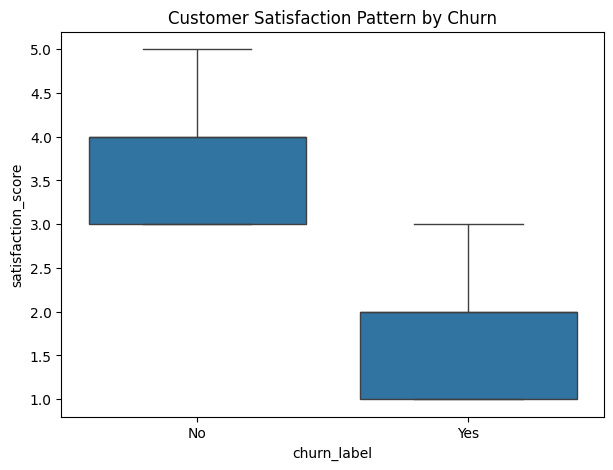

In [171]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_clean,
    x='churn_label',
    y='satisfaction_score'
)

plt.title('Customer Satisfaction Pattern by Churn')

plt.show()

Customer satisfaction shows a strong relationship with churn behavior. Customers who churned have a significantly lower average satisfaction score (1.74) compared to customers who stayed (3.77). Meanwhile, newly joined customers have the highest satisfaction score (3.97). This indicates that maintaining customer satisfaction during the service lifecycle is an important factor in reducing churn risk.

### Service Usage Pattern

In [172]:
df_clean.groupby(
    ['internet_type','churn_label']
)['satisfaction_score'].mean()

internet_type        churn_label
Cable                No             3.685575
                     Yes            1.615023
DSL                  No             3.672119
                     Yes            1.674267
Fiber Optic          No             3.753752
                     Yes            1.744337
No Internet Service  No             3.993631
                     Yes            2.044248
Name: satisfaction_score, dtype: float64

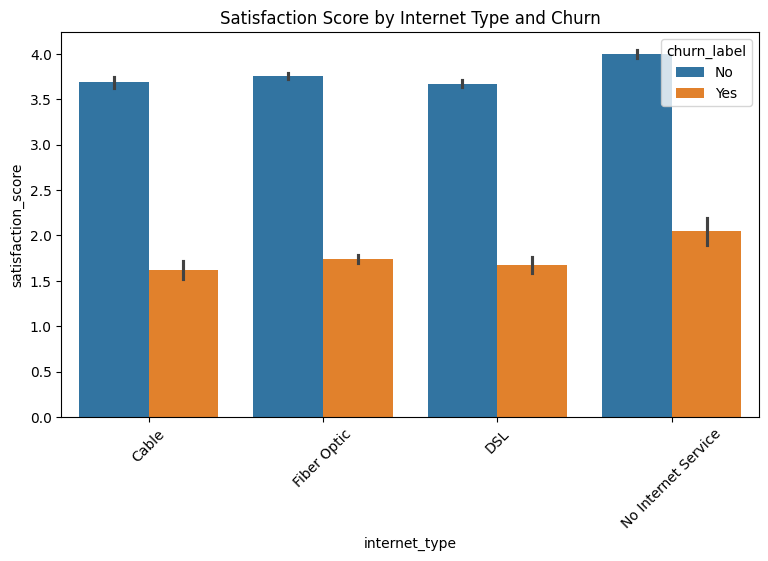

In [173]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='internet_type',
    y='satisfaction_score',
    hue='churn_label'
)

plt.title(
    'Satisfaction Score by Internet Type and Churn'
)

plt.xticks(rotation=45)

plt.show()

The analysis between internet type and satisfaction score shows a consistent pattern across all service categories. Customers who churned have significantly lower satisfaction scores compared to customers who stayed. Although Fiber Optic customers show a higher churn rate compared to other internet types, the churn behavior is also associated with low satisfaction scores. This indicates that customer experience and satisfaction may play an important role in explaining churn behavior.

### Monthly Charges & Contract Pattern

In [174]:
df_clean.groupby(
    ['contract','churn_label']
)['monthly_charges'].mean()

contract        churn_label
Month-to-Month  No             59.293632
                Yes            73.019396
One Year        No             63.332262
                Yes            85.050904
Two Year        No             61.806458
                Yes            86.777083
Name: monthly_charges, dtype: float64

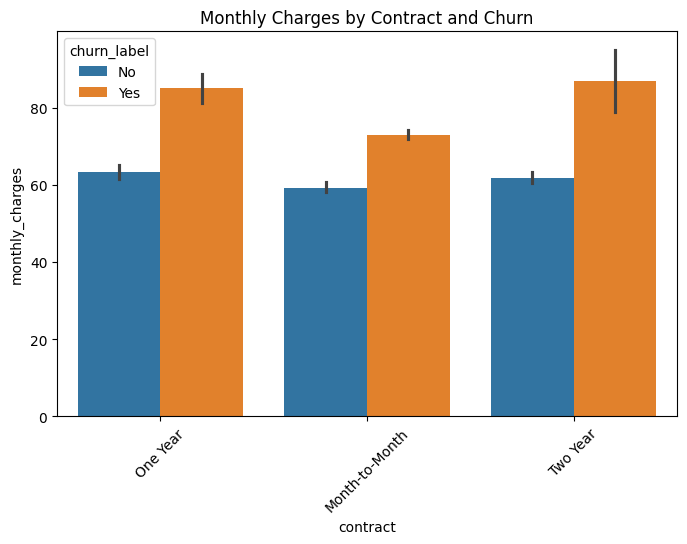

In [175]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='contract',
    y='monthly_charges',
    hue='churn_label'
)

plt.title(
    'Monthly Charges by Contract and Churn'
)

plt.xticks(rotation=45)

plt.show()

Insight: Monthly charges differ across contract types and churn status. Within the same contract type, churned customers tend to have higher average monthly charges than retained customers.

### Payment Method Pattern

In [176]:
pd.crosstab(
    [
        df_clean['payment_method'],
        df_clean['contract']
    ],
    df_clean['churn_label'],
    normalize='index'
)*100

churn_label                                      No        Yes
payment_method            contract                            
Bank transfer (automatic) Month-to-Month  63.051471  36.948529
                          One Year        90.640394   9.359606
                          Two Year        96.801347   3.198653
Credit card (automatic)   Month-to-Month  64.471058  35.528942
                          One Year        90.000000  10.000000
                          Two Year        97.872340   2.127660
Electronic check          Month-to-Month  41.391509  58.608491
                          One Year        83.631714  16.368286
                          Two Year        95.323741   4.676259
Mailed check              Month-to-Month  67.548907  32.451093
                          One Year        93.294461   6.705539
                          Two Year        99.250000   0.750000

The analysis of payment method and contract combination shows that contract type plays an important role in customer churn behavior. Customers with Month-to-Month contracts consistently demonstrate higher churn rates compared to customers with One Year or Two Year contracts across all payment methods. The highest churn rate is observed among customers using Electronic Check with Month-to-Month contracts (58.61%). Meanwhile, customers with long-term contracts show significantly lower churn rates, indicating stronger customer retention among long-term subscribers.

# Summary of Key Findings

Based on the exploratory data analysis, several customer characteristics show
notable associations with churn.

1. Customer Satisfaction Shows the Strongest Numerical Association with Churn
Customer satisfaction has a strong negative correlation with churn
(r ≈ -0.75). Churned customers have an average satisfaction score of
approximately 1.74, compared with 3.77 among retained customers.

This indicates that customers with lower satisfaction levels are substantially
more represented among churned customers.

2. Month-to-Month Customers Have a Substantially Higher Churn Rate
Customers with Month-to-Month contracts have a churn rate of approximately
45.84%, compared with only 2.55% among customers with Two-Year contracts.

This suggests that customers without longer-term contract commitments represent
an important segment in the observed churn pattern.

3. Churn Is Concentrated Among Early-Tenure Customers

Churn rate shows a clear declining pattern as customer tenure increases.
Customers within their first 12 months have the highest churn rate at
**47.44%**, compared with **28.71%** for 13–24 months, **20.39%** for
25–48 months, and only **9.51%** for customers with more than 48 months
of tenure.

This indicates that customers in the earlier stages of their lifecycle
represent an important segment for customer retention initiatives.

This pattern indicates that customers earlier in their lifecycle are more
represented among churned customers.

4. Churned Customers Tend to Have Higher Monthly Charges
The average monthly charge among churned customers is approximately 74.44,
compared with 61.27 among retained customers.

This suggests an association between higher monthly charges and churn,
although the analysis does not establish that higher charges directly cause
customers to leave.

5. Certain Customer Characteristics Form Higher-Churn Segments
Differences in churn were also observed across payment methods, internet
services, offers, and other customer characteristics.

One notable segment is customers using Electronic Check with Month-to-Month
contracts, which shows a churn rate of approximately 58.61% in the analyzed
data.

These results suggest that churn is associated with a combination of customer
experience, contract characteristics, tenure, charges, and service/payment
behavior rather than a single factor.

# Business Insights

The analysis indicates that customer churn is concentrated in several
identifiable customer segments rather than being evenly distributed across
the customer base.

Low customer satisfaction appears to be an important warning signal, while
Month-to-Month contracts and shorter customer tenure are associated with
higher churn. Customers with higher monthly charges also show higher churn
on average.

From a business perspective, these patterns suggest that retention efforts
can be more targeted. Instead of applying the same retention strategy to all
customers, the company can prioritize customers who exhibit multiple
higher-churn characteristics.

# Business Recommendations

1. Prioritize customers with low satisfaction
2. Focus retention campaigns on Month-to-Month customers
3. Strengthen retention during early customer lifecycle
4. Review offers for customers with higher monthly charges
5. Prioritize high-risk customer segments

# Save Dataset

In [177]:
# Create final cleaned dataset
df_clean = df.copy()

# Final quality check
print("Final dataset shape:", df_clean.shape)
print("Total customers:", df_clean["customer_id"].nunique())
print("Duplicate customer IDs:", df_clean["customer_id"].duplicated().sum())
print("Total missing values:", df_clean.isnull().sum().sum())

# Export dataset
df_clean.to_csv("customer_churn_clean.csv", index=False)

Final dataset shape: (7043, 52)
Total customers: 7043
Duplicate customer IDs: 0
Total missing values: 0


In [178]:
from google.colab import files

files.download("customer_churn_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>